**Objective**: In this lab, you will implement and compare manual grid search with scikit-learn's built-in `GridSearchCV` and `RandomizedSearchCV` for hyperparameter tuning. You'll work with multiple classification algorithms and combine them using voting classifiers.

**Learning Goals**:
- Understand hyperparameter tuning through exhaustive and randomized search.
- Compare manual implementation with built-in functions.
- Analyze the impact of feature scaling (`StandardScaler` vs `MinMaxScaler`) on distance-based vs. tree-based models.
- Create and evaluate voting classifiers.
- Visualize model performance using ROC curves and confusion matrices.

**Datasets Used**:
1. Wine Quality - Predicting wine quality based on chemical properties
2. HR Attrition - Predicting employee turnover
3. Banknote Authentication - Detecting counterfeit banknotes
4. QSAR Biodegradation - Predicting chemical biodegradability


## Part 1: Import Libraries and Setup

First, let's import all the necessary libraries for our machine learning pipeline.

In [1]:
import pandas as pd
import numpy as np
import itertools
import time
import matplotlib.pyplot as plt
from scipy.stats import randint
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
# Bypass SSL certificate verification for dataset downloads
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Models and Parameter Grids

Here we define the classifiers we'll tune and their respective hyperparameter grids.

In [2]:
# The parameter names must match the pipeline step names, e.g., 'classifier__max_depth'
# ToDo: Define base models (Decision Tree, kNN)
# Hint: The scaler itself can be treated as a hyperparameter by passing [StandardScaler(), MinMaxScaler()] to the grid.

param_grid_dt = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'select__k': [5, 10, 'all'],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

param_grid_knn = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'select__k': [5, 10, 'all'],
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance']
}

# ToDo: Create a list of (classifier, param_grid, name) tuples
classifiers_to_tune = [
    (DecisionTreeClassifier(random_state=42), param_grid_dt, 'Decision Tree'),
    (KNeighborsClassifier(), param_grid_knn, 'kNN')
]

## Dataset Loading Functions
We'll work with four different datasets to test our algorithms across various domains.

### 3.1 Wine Quality Dataset


In [3]:
def load_wine_quality():
    """Load Wine Quality dataset"""
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        data = pd.read_csv(url, sep=';')
    except Exception as e:
        print(f"Error loading Wine Quality dataset: {e}")
        return None, None, None, None, "Wine Quality (Failed)"

    # Create the binary target variable 'good_quality'
    data['good_quality'] = (data['quality'] > 5).astype(int)
    X = data.drop(['quality', 'good_quality'], axis=1)
    y = data['good_quality']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print("Wine Quality dataset loaded and preprocessed successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "Wine Quality"

### 3.2 HR Attrition Dataset


In [4]:
def load_hr_attrition():
    """Load IBM HR Attrition dataset"""
    try:
        data = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
    except FileNotFoundError:
        print("HR Attrition dataset not found. Please place 'WA_Fn-UseC_-HR-Employee-Attrition.csv' inside a 'data/' folder.")
        return None, None, None, None, "HR Attrition (Failed)"

    # Target: Attrition = Yes (1), No (0)
    data['Attrition'] = (data['Attrition'] == 'Yes').astype(int)

    # Drop ID-like column
    X = data.drop(['EmployeeNumber', 'Attrition'], axis=1, errors='ignore')
    y = data['Attrition']

    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("IBM HR Attrition dataset loaded and preprocessed successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "HR Attrition"

### 3.3 Banknote Authentication Dataset


In [5]:
def load_banknote():
    """Load Banknote Authentication dataset"""
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

    try:
        data = pd.read_csv(url, header=None)
    except Exception as e:
        print(f"Error loading Banknote dataset: {e}")
        return None, None, None, None, "Banknote (Failed)"

    # According to UCI: variance, skewness, curtosis, entropy, class (0=authentic, 1=fake)
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("Banknote Authentication dataset loaded successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "Banknote Authentication"

### 3.4 QSAR Biodegradation Dataset


In [6]:
def load_qsar_biodegradation():
    """Load QSAR Biodegradation dataset"""
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

    try:
        data = pd.read_csv(url, sep=';', header=None)
    except Exception as e:
        print(f"Error loading QSAR dataset: {e}")
        return None, None, None, None, "QSAR (Failed)"

    # Last column is target (RB = ready biodegradable, NRB = not)
    X = data.iloc[:, :-1]
    y = (data.iloc[:, -1] == 'RB').astype(int)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("QSAR Biodegradation dataset loaded successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "QSAR Biodegradation"

## Part 4: Manual Grid Search Implementation


In [7]:
def run_manual_grid_search(X_train, y_train, dataset_name):
    """Run manual grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING MANUAL GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    best_estimators = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_features = X_train.shape[1]

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"--- Manual Grid Search for {name} ---")
        best_score = -1
        best_params = None

        # TODO: Implement manual grid search for hyperparameter tuning.
        # Steps to implement:
        # 1. Adjust the feature selection parameter grid to ensure 'k' does not exceed the number of features.
        adjusted_param_grid = {}
        for key, values in param_grid.items():
            if key == 'select__k':
                adjusted_values = list(dict.fromkeys(
                    v for v in values if v == 'all' or v <= n_features
                ))
                if not adjusted_values:
                    adjusted_values = ['all']
                adjusted_param_grid[key] = adjusted_values
            else:
                adjusted_param_grid[key] = values

        # 2. Generate all combinations of hyperparameters from the adjusted parameter grid.
        keys = list(adjusted_param_grid.keys())
        value_lists = list(adjusted_param_grid.values())
        all_combinations = list(itertools.product(*value_lists))

        for combo in all_combinations:
            params = dict(zip(keys, combo))

            # 3. For each parameter combination, perform cross-validation (5-fold StratifiedKFold).
            fold_aucs = []
            for train_idx, val_idx in cv.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

                # 4. Build a pipeline with scaling, feature selection, and the classifier.
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('select', SelectKBest(score_func=f_classif)),
                    ('classifier', classifier_instance)
                ])
                pipeline.set_params(**params)

                # 5. Fit the pipeline, predict probabilities, and compute the mean AUC for the combination.
                pipeline.fit(X_tr, y_tr)
                y_val_proba = pipeline.predict_proba(X_val)[:, 1]
                fold_aucs.append(roc_auc_score(y_val, y_val_proba))

            mean_auc = np.mean(fold_aucs)

            # 6. Track and print the best parameter combination and its mean AUC.
            if mean_auc > best_score:
                best_score = mean_auc
                best_params = params

        print("-" * 90)
        print(f"Best parameters for {name}: {best_params}")
        print(f"Best cross-validation AUC: {best_score:.4f}")

        # TODO: Create the final pipeline using the best_params.
        # Fit the final pipeline on the full training data and store it in best_estimators[name].
        final_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif)),
            ('classifier', classifier_instance)
        ])
        final_pipeline.set_params(**best_params)
        final_pipeline.fit(X_train, y_train)
        best_estimators[name] = final_pipeline

    return best_estimators

**Understanding the Manual Implementation**:
- **Nested Cross-Validation**: For each parameter combination, we perform 5-fold CV
- **Pipeline Integration**: Each step (scaling, feature selection, classification) is properly chained
- **AUC Scoring**: We use Area Under the ROC Curve as our optimization metric
- **Best Model Selection**: The combination with highest mean AUC across folds is selected

## Part 5: Built-in Grid Search Implementation

Now let's compare our manual implementation with scikit-learn's `GridSearchCV`.

**Advantages of Built-in GridSearchCV**:
- **Parallel Processing**: Uses `n_jobs=-1` for faster computation
- **Cleaner Code**: Less verbose than manual implementation
- **Built-in Features**: Automatic best model selection and scoring

In [8]:
def run_builtin_grid_search(X_train, y_train, dataset_name):
    """Run built-in grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING BUILT-IN GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    results_builtin = {}
    n_features = X_train.shape[1]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"\n--- GridSearchCV for {name} ---")

        # TODO: Implement built-in grid search for each classifier:
        # - Adjust feature selection parameter grid based on dataset size (n_features).
        adjusted_param_grid = dict(param_grid)
        if 'select__k' in adjusted_param_grid:
            adjusted_k = list(dict.fromkeys(
                v for v in adjusted_param_grid['select__k'] if v == 'all' or v <= n_features
            ))
            if not adjusted_k:
                adjusted_k = ['all']
            adjusted_param_grid['select__k'] = adjusted_k

        # - Create a pipeline with a default scaler, SelectKBest, and the classifier.
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif)),
            ('classifier', classifier_instance)
        ])

        # - Run GridSearchCV with the pipeline and adjusted param grid.
        grid_search = GridSearchCV(
            pipeline, adjusted_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1
        )

        # - Use the `time` module to record execution time.
        start_time = time.time()

        # - Fit grid search on training data and collect best estimator, score, params, and time.
        grid_search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best CV AUC: {grid_search.best_score_:.4f}")
        print(f"Time taken: {elapsed_time:.2f} seconds")

        results_builtin[name] = {
            'best_estimator': grid_search.best_estimator_,
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'time': elapsed_time
        }

    return results_builtin

## Part 6: Randomized Search Integration

To evaluate the trade-off between exhaustive search and randomized combinations, we'll implement `RandomizedSearchCV`.

In [9]:
def run_randomized_search(X_train, y_train, dataset_name):
    """Run randomized search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING RANDOMIZED SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    results_random = {}
    n_features = X_train.shape[1]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # TODO: Implement RandomizedSearchCV for each classifier.
    # 1. Define a parameter distribution (using scipy.stats.randint) for Decision Tree and kNN.
    valid_k = list(dict.fromkeys(v for v in [5, 10, 'all'] if v == 'all' or v <= n_features)) or ['all']

    param_dist_dt = {
        'scaler': [StandardScaler(), MinMaxScaler()],
        'select__k': valid_k,
        'classifier__max_depth': randint(2, 20),
        'classifier__min_samples_split': randint(2, 20)
    }

    param_dist_knn = {
        'scaler': [StandardScaler(), MinMaxScaler()],
        'select__k': valid_k,
        'classifier__n_neighbors': randint(1, 20),
        'classifier__weights': ['uniform', 'distance']
    }

    param_distributions = {'Decision Tree': param_dist_dt, 'kNN': param_dist_knn}

    # 2. Iterate through the classifiers, building the pipeline.
    for classifier_instance, _, name in classifiers_to_tune:
        print(f"\n--- RandomizedSearchCV for {name} ---")

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif)),
            ('classifier', classifier_instance)
        ])

        # 3. Use RandomizedSearchCV with n_iter=10.
        random_search = RandomizedSearchCV(
            pipeline, param_distributions[name], n_iter=10,
            scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42
        )

        # 4. Measure execution time.
        start_time = time.time()
        random_search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        print(f"Best parameters: {random_search.best_params_}")
        print(f"Best CV AUC: {random_search.best_score_:.4f}")
        print(f"Time taken: {elapsed_time:.2f} seconds")

        # 5. Store best estimator, score, params, and execution time in results_random.
        results_random[name] = {
            'best_estimator': random_search.best_estimator_,
            'best_score': random_search.best_score_,
            'best_params': random_search.best_params_,
            'time': elapsed_time
        }

    return results_random

## Part 7: Model Evaluation and Voting Classifiers

This function evaluates individual models and creates voting classifiers to combine their predictions.

In [10]:
def evaluate_models(X_test, y_test, best_estimators, dataset_name, method_name="Manual"):
    """Evaluate models and create visualizations"""
    print(f"\n{'='*60}")
    print(f"EVALUATING {method_name.upper()} MODELS FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    # Individual model evaluation
    print(f"\n--- Individual Model Performance ---")
    for name, model in best_estimators.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  F1-Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    # Voting Classifier
    print(f"\n--- {method_name} Voting Classifier ---")

    if method_name == "Manual":
        # Manual voting implementation
        y_pred_votes = []
        y_pred_proba_avg = []

        for i in range(len(X_test)):
            votes = []
            probas = []

            for name, model in best_estimators.items():
                pred = model.predict(X_test.iloc[[i]])[0]
                proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
                votes.append(pred)
                probas.append(proba)

            majority_vote = 1 if np.mean(votes) > 0.5 else 0
            avg_proba = np.mean(probas)

            y_pred_votes.append(majority_vote)
            y_pred_proba_avg.append(avg_proba)

        y_pred_votes = np.array(y_pred_votes)
        y_pred_proba_avg = np.array(y_pred_proba_avg)

    else:  # Built-in
        # Create VotingClassifier
        estimators = [(name, model) for name, model in best_estimators.items()]
        voting_clf = VotingClassifier(estimators=estimators, voting='soft')
        voting_clf.fit(X_train, y_train)  # Note: This assumes X_train, y_train are in scope

        y_pred_votes = voting_clf.predict(X_test)
        y_pred_proba_avg = voting_clf.predict_proba(X_test)[:, 1]

    # Compute voting metrics
    accuracy = accuracy_score(y_test, y_pred_votes)
    precision = precision_score(y_test, y_pred_votes, zero_division=0)
    recall = recall_score(y_test, y_pred_votes, zero_division=0)
    f1 = f1_score(y_test, y_pred_votes, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba_avg)

    print(f"Voting Classifier Performance:")
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

    # Visualizations
    # ROC Curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for name, model in best_estimators.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

    # Add voting classifier to ROC
    fpr_vote, tpr_vote, _ = roc_curve(y_test, y_pred_proba_avg)
    plt.plot(fpr_vote, tpr_vote, label=f'Voting (AUC = {auc:.3f})', linewidth=3, linestyle='--')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {dataset_name} ({method_name})')
    plt.legend()
    plt.grid(True)

    # Confusion Matrix for Voting Classifier
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred_votes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), cmap="Blues")
    plt.title(f'Voting Classifier - {dataset_name} ({method_name})')

    plt.tight_layout()
    plt.show()

    return y_pred_votes, y_pred_proba_avg

## Part 8: Complete Pipeline Function

This function orchestrates the entire experiment for each dataset.

In [11]:
def run_complete_pipeline(dataset_loader, dataset_name):
    """Run complete pipeline for a dataset"""
    print(f"\n{'#'*80}")
    print(f"PROCESSING DATASET: {dataset_name.upper()}")
    print(f"{'#'*80}")

    # Global assignment so voting classifier in evaluate_models can access it
    global X_train, y_train
    X_train, X_test, y_train, y_test, actual_name = dataset_loader()
    if X_train is None:
        print(f"Skipping {dataset_name} due to loading error.")
        return

    print("-" * 30)

    # Part 1: Manual Implementation
    manual_estimators = run_manual_grid_search(X_train, y_train, actual_name)
    if manual_estimators:
        evaluate_models(X_test, y_test, manual_estimators, actual_name, "Manual")

    # Part 2: Built-in Implementation
    builtin_results = run_builtin_grid_search(X_train, y_train, actual_name)
    if builtin_results:
        builtin_estimators = {name: results['best_estimator'] for name, results in builtin_results.items()}
        evaluate_models(X_test, y_test, builtin_estimators, actual_name, "Built-in")

    # Part 3: Randomized Search Implementation
    random_results = run_randomized_search(X_train, y_train, actual_name)
    if random_results:
        random_estimators = {name: results['best_estimator'] for name, results in random_results.items()}
        evaluate_models(X_test, y_test, random_estimators, actual_name, "Randomized")

    print(f"\nCompleted processing for {actual_name}")
    print("="*80)

## Part 9: Execute the Complete Lab

Now let's run our pipeline on all four datasets!


################################################################################
PROCESSING DATASET: WINE QUALITY
################################################################################
Wine Quality dataset loaded and preprocessed successfully.
Training set shape: (1119, 11)
Testing set shape: (480, 11)
------------------------------

RUNNING MANUAL GRID SEARCH FOR WINE QUALITY
--- Manual Grid Search for Decision Tree ---
------------------------------------------------------------------------------------------
Best parameters for Decision Tree: {'scaler': MinMaxScaler(), 'select__k': 5, 'classifier__max_depth': 5, 'classifier__min_samples_split': 5}
Best cross-validation AUC: 0.7841
--- Manual Grid Search for kNN ---
------------------------------------------------------------------------------------------
Best parameters for kNN: {'scaler': MinMaxScaler(), 'select__k': 5, 'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}
Best cross-validation AUC: 0.8687

EVA

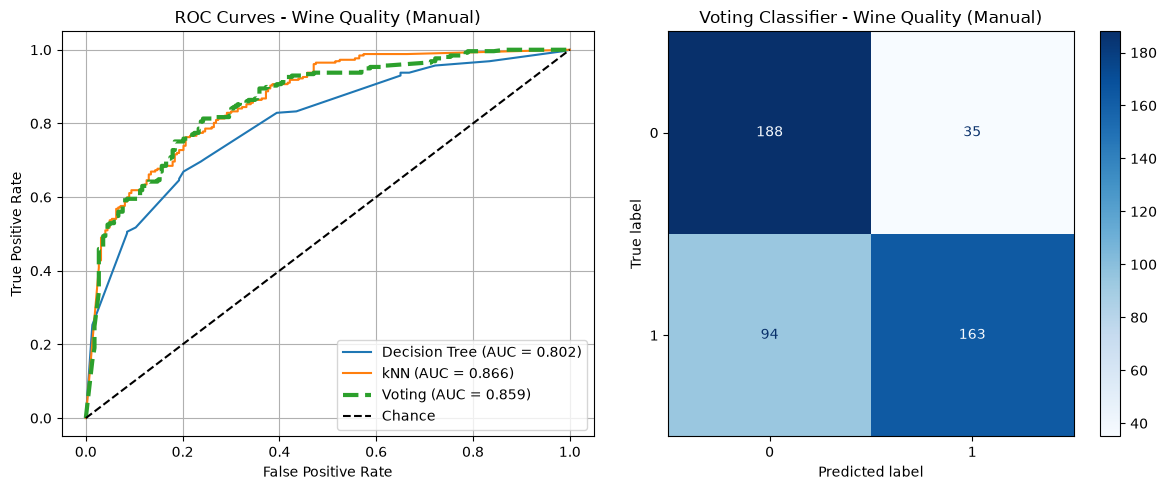


RUNNING BUILT-IN GRID SEARCH FOR WINE QUALITY

--- GridSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'scaler': MinMaxScaler(), 'select__k': 5}
Best CV AUC: 0.7841
Time taken: 4.81 seconds

--- GridSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance', 'scaler': MinMaxScaler(), 'select__k': 5}
Best CV AUC: 0.8687
Time taken: 0.38 seconds

EVALUATING BUILT-IN MODELS FOR WINE QUALITY

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.7271
  Precision: 0.7716
  Recall: 0.6965
  F1-Score: 0.7321
  ROC AUC: 0.8025

kNN:
  Accuracy: 0.7729
  Precision: 0.8008
  Recall: 0.7665
  F1-Score: 0.7833
  ROC AUC: 0.8661

--- Built-in Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.7833, Precision: 0.7954
  Recall: 0.8016, F1: 0.7984, AUC: 0.8592


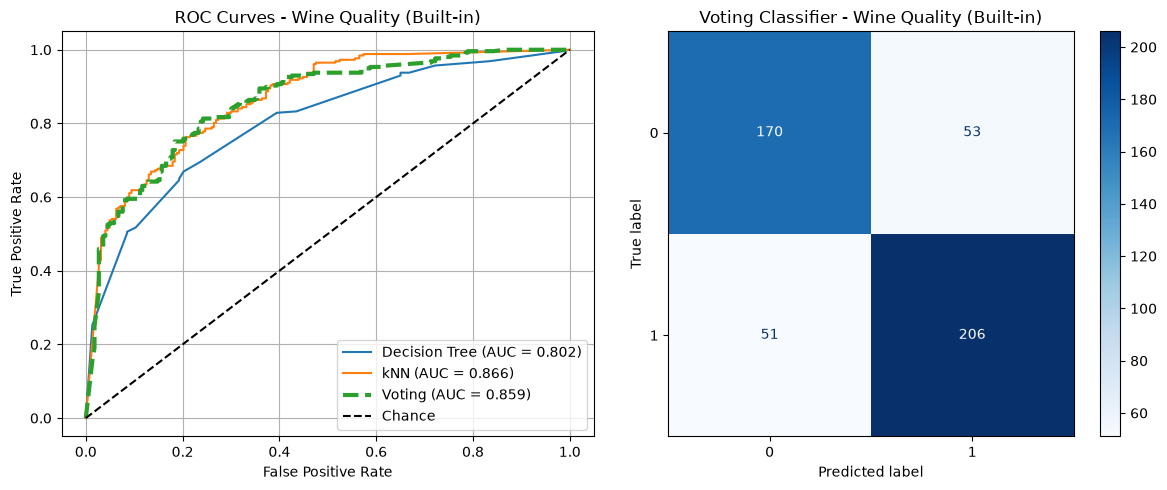


RUNNING RANDOMIZED SEARCH FOR WINE QUALITY

--- RandomizedSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 8, 'scaler': MinMaxScaler(), 'select__k': 5}
Best CV AUC: 0.7723
Time taken: 0.20 seconds

--- RandomizedSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'scaler': StandardScaler(), 'select__k': 5}
Best CV AUC: 0.8670
Time taken: 0.11 seconds

EVALUATING RANDOMIZED MODELS FOR WINE QUALITY

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.7500
  Precision: 0.7819
  Recall: 0.7393
  F1-Score: 0.7600
  ROC AUC: 0.7968

kNN:
  Accuracy: 0.7771
  Precision: 0.7863
  Recall: 0.8016
  F1-Score: 0.7938
  ROC AUC: 0.8745

--- Randomized Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.7771, Precision: 0.7820
  Recall: 0.8093, F1: 0.7954, AUC: 0.8641


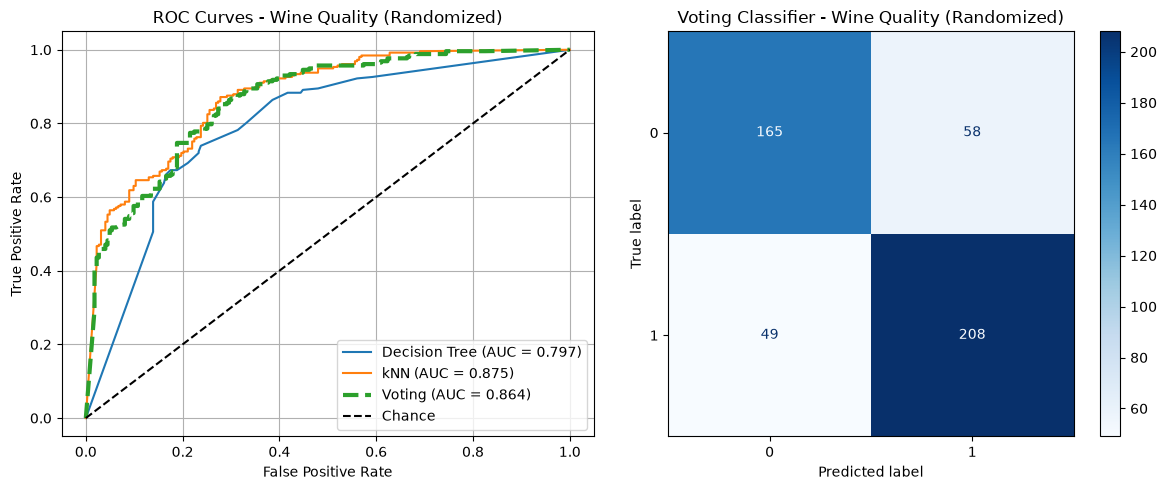


Completed processing for Wine Quality

################################################################################
PROCESSING DATASET: HR ATTRITION
################################################################################
HR Attrition dataset not found. Please place 'WA_Fn-UseC_-HR-Employee-Attrition.csv' inside a 'data/' folder.
Skipping HR Attrition due to loading error.

################################################################################
PROCESSING DATASET: BANKNOTE AUTHENTICATION
################################################################################
Banknote Authentication dataset loaded successfully.
Training set shape: (960, 4)
Testing set shape: (412, 4)
------------------------------

RUNNING MANUAL GRID SEARCH FOR BANKNOTE AUTHENTICATION
--- Manual Grid Search for Decision Tree ---
------------------------------------------------------------------------------------------
Best parameters for Decision Tree: {'scaler': StandardScaler(), 'select

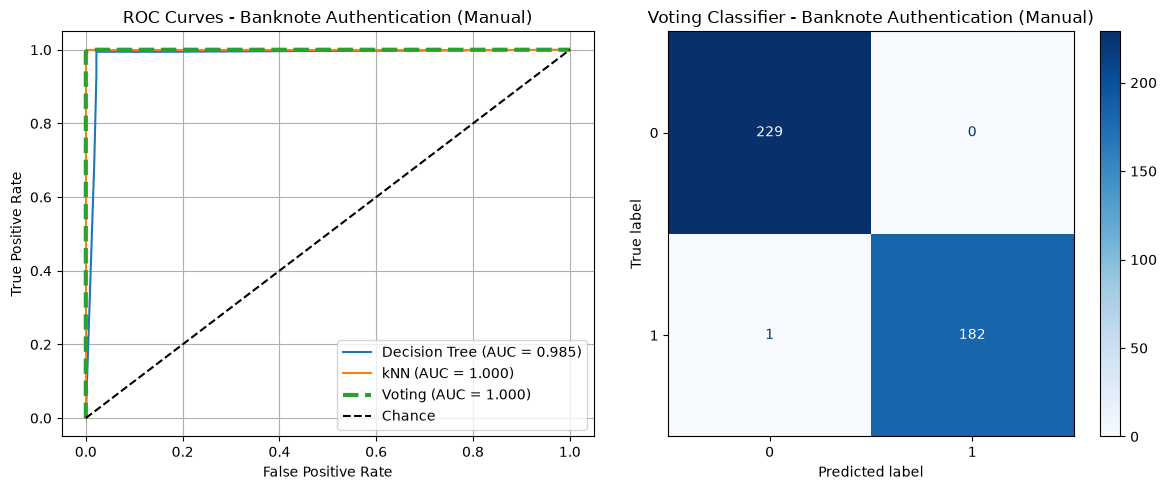


RUNNING BUILT-IN GRID SEARCH FOR BANKNOTE AUTHENTICATION

--- GridSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.9856
Time taken: 0.18 seconds

--- GridSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance', 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.9990
Time taken: 0.13 seconds

EVALUATING BUILT-IN MODELS FOR BANKNOTE AUTHENTICATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.9854
  Precision: 0.9733
  Recall: 0.9945
  F1-Score: 0.9838
  ROC AUC: 0.9847

kNN:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000

--- Built-in Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.9976, Precision: 1.0000
  Recall: 0.9945, F1: 0.9973, AUC: 1.0000


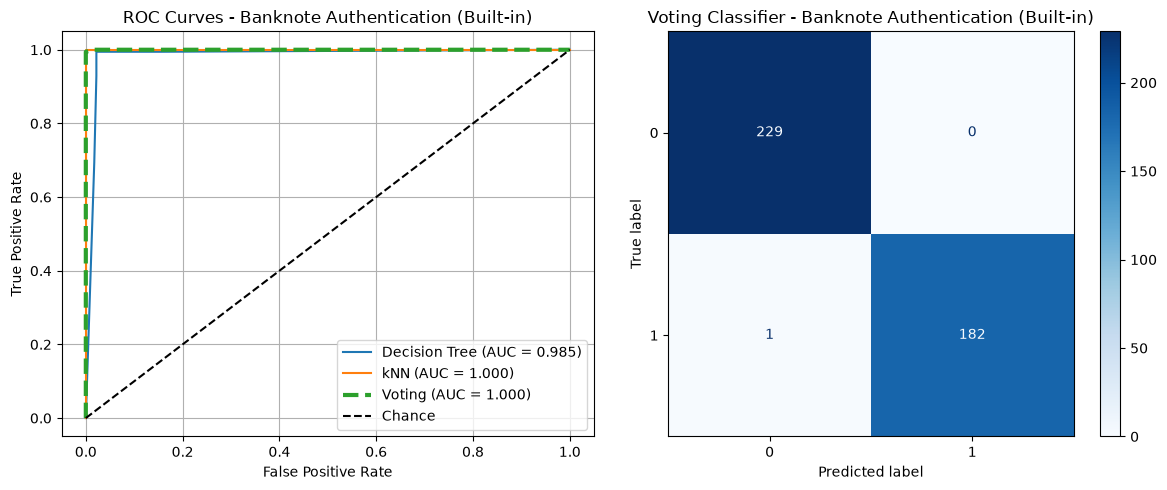


RUNNING RANDOMIZED SEARCH FOR BANKNOTE AUTHENTICATION

--- RandomizedSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 8, 'classifier__min_samples_split': 16, 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.9860
Time taken: 0.10 seconds

--- RandomizedSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 15, 'classifier__weights': 'uniform', 'scaler': MinMaxScaler(), 'select__k': 'all'}
Best CV AUC: 0.9999
Time taken: 0.10 seconds

EVALUATING RANDOMIZED MODELS FOR BANKNOTE AUTHENTICATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.9830
  Precision: 0.9681
  Recall: 0.9945
  F1-Score: 0.9811
  ROC AUC: 0.9858

kNN:
  Accuracy: 0.9903
  Precision: 0.9786
  Recall: 1.0000
  F1-Score: 0.9892
  ROC AUC: 1.0000

--- Randomized Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.9951, Precision: 0.9945
  Recall: 0.9945, F1: 0.9945, AUC: 0.9999


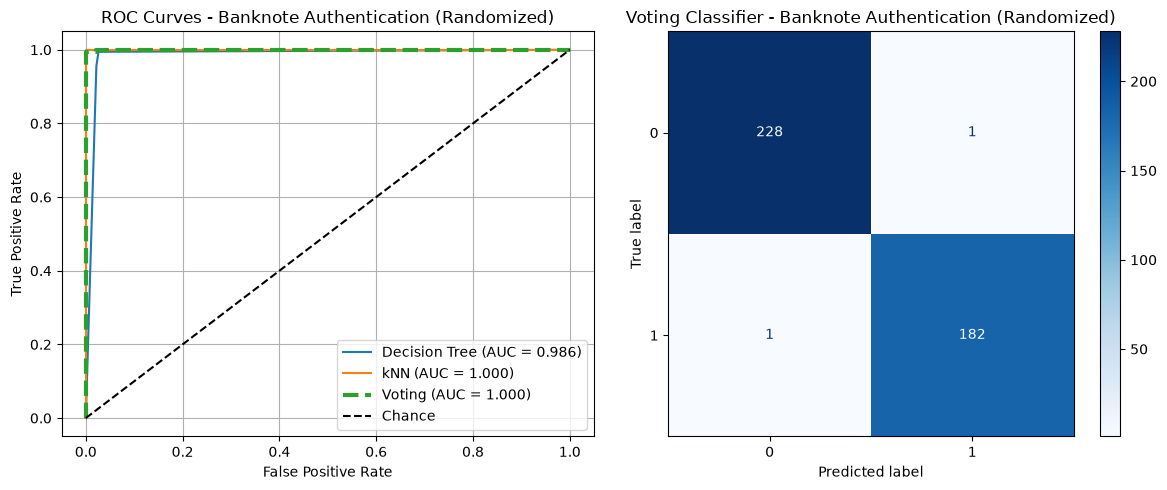


Completed processing for Banknote Authentication

################################################################################
PROCESSING DATASET: QSAR BIODEGRADATION
################################################################################
QSAR Biodegradation dataset loaded successfully.
Training set shape: (738, 41)
Testing set shape: (317, 41)
------------------------------

RUNNING MANUAL GRID SEARCH FOR QSAR BIODEGRADATION
--- Manual Grid Search for Decision Tree ---
------------------------------------------------------------------------------------------
Best parameters for Decision Tree: {'scaler': StandardScaler(), 'select__k': 'all', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Best cross-validation AUC: 0.8369
--- Manual Grid Search for kNN ---
------------------------------------------------------------------------------------------
Best parameters for kNN: {'scaler': StandardScaler(), 'select__k': 'all', 'classifier__n_neighbors': 5, 'classif

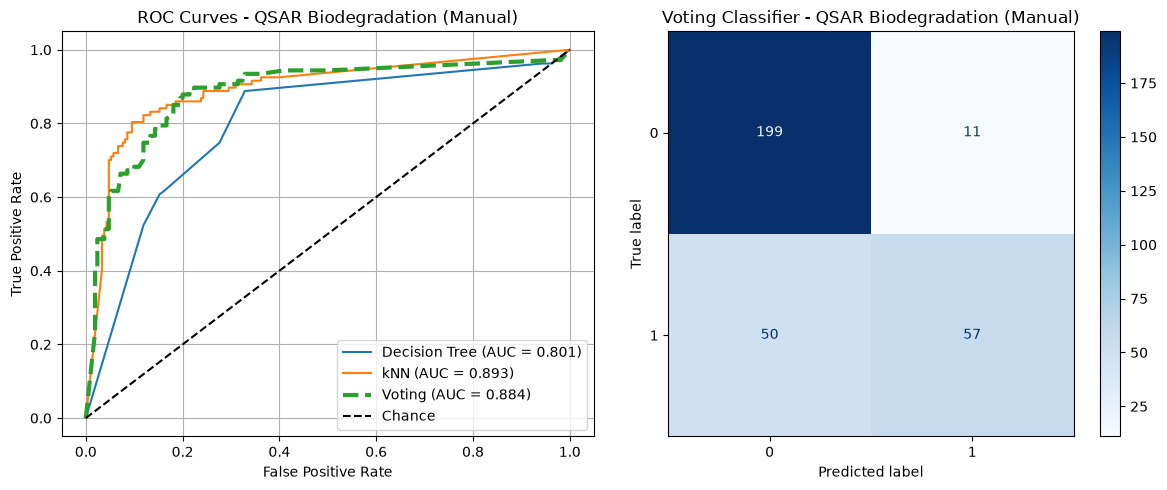


RUNNING BUILT-IN GRID SEARCH FOR QSAR BIODEGRADATION

--- GridSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.8369
Time taken: 0.62 seconds

--- GridSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 5, 'classifier__weights': 'distance', 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.9002
Time taken: 0.47 seconds

EVALUATING BUILT-IN MODELS FOR QSAR BIODEGRADATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.7634
  Precision: 0.6600
  Recall: 0.6168
  F1-Score: 0.6377
  ROC AUC: 0.8007

kNN:
  Accuracy: 0.8644
  Precision: 0.8077
  Recall: 0.7850
  F1-Score: 0.7962
  ROC AUC: 0.8931

--- Built-in Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.8328, Precision: 0.7547
  Recall: 0.7477, F1: 0.7512, AUC: 0.8843


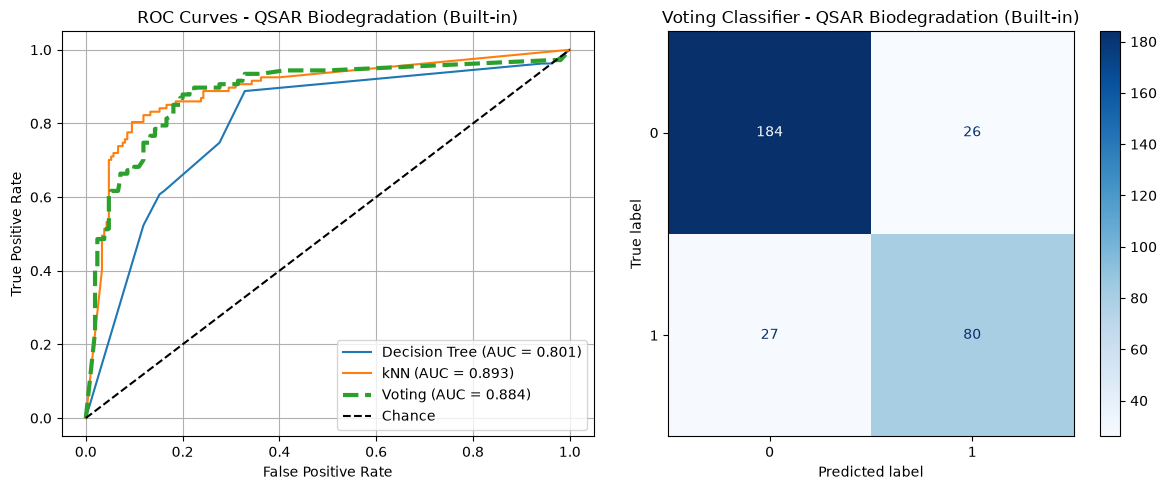


RUNNING RANDOMIZED SEARCH FOR QSAR BIODEGRADATION

--- RandomizedSearchCV for Decision Tree ---
Best parameters: {'classifier__max_depth': 4, 'classifier__min_samples_split': 6, 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.8393
Time taken: 0.16 seconds

--- RandomizedSearchCV for kNN ---
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance', 'scaler': StandardScaler(), 'select__k': 'all'}
Best CV AUC: 0.8997
Time taken: 0.14 seconds

EVALUATING RANDOMIZED MODELS FOR QSAR BIODEGRADATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.7823
  Precision: 0.6696
  Recall: 0.7009
  F1-Score: 0.6849
  ROC AUC: 0.8176

kNN:
  Accuracy: 0.8454
  Precision: 0.7685
  Recall: 0.7757
  F1-Score: 0.7721
  ROC AUC: 0.9005

--- Randomized Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 0.8328, Precision: 0.7411
  Recall: 0.7757, F1: 0.7580, AUC: 0.8907


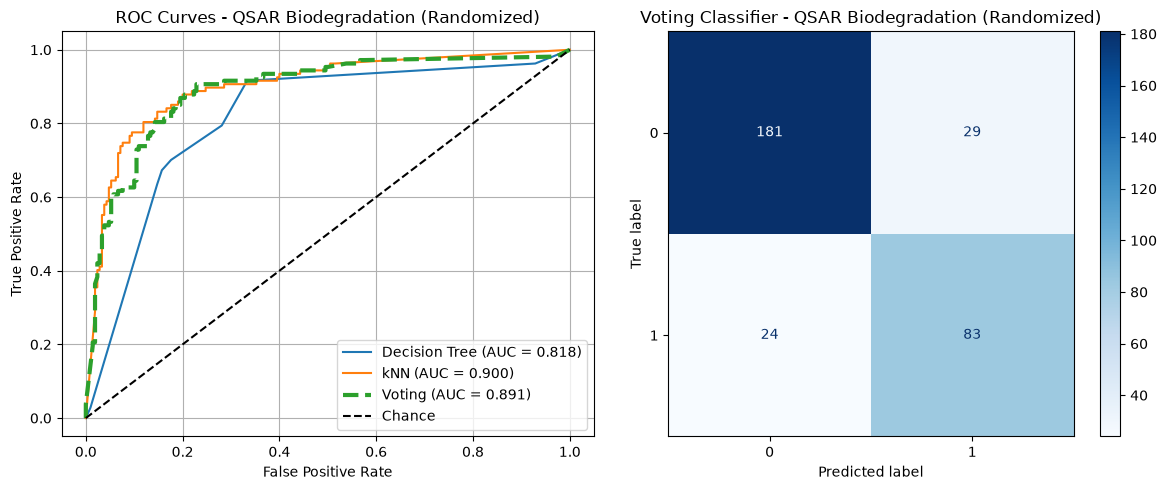


Completed processing for QSAR Biodegradation

ALL DATASETS PROCESSED!


In [12]:
# --- Run Pipeline for All Datasets ---
datasets = [
    (load_wine_quality, "Wine Quality"),
    (load_hr_attrition, "HR Attrition"),
    (load_banknote, "Banknote Authentication"),
    (load_qsar_biodegradation, "QSAR Biodegradation")
]

# Run for each dataset
for dataset_loader, dataset_name in datasets:
    try:
        run_complete_pipeline(dataset_loader, dataset_name)
    except Exception as e:
        print(f"Error processing {dataset_name}: {e}")
        continue

print("\n" + "="*80)
print("ALL DATASETS PROCESSED!")
print("="*80)
